# Лабораторная № 1

Вариант 1

----

## Задача 1 

Зарплаты медсестёр

In [21]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from scipy import stats

data = pd.read_csv('/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/лаба1/Nursing Home Data/Nursing Home Data_data', sep='\s+')
data = data[['NSAL', "RURAL"]]
rural = data.query("RURAL == 1")
city = data.query("RURAL == 0")

<Axes: >

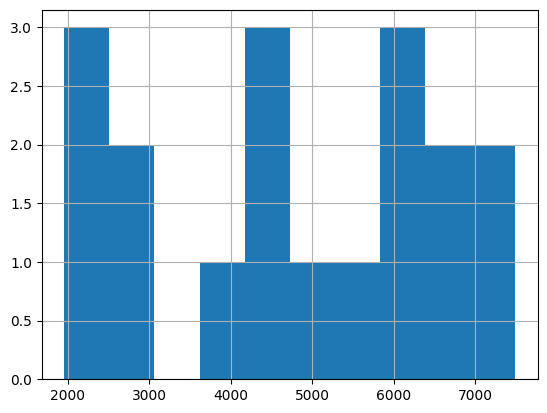

In [22]:
city['NSAL'].hist()

<Axes: >

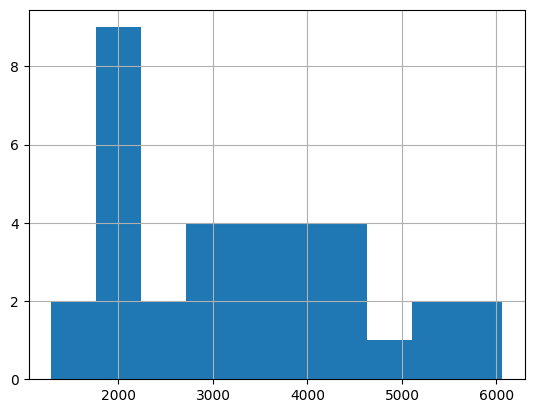

In [23]:
rural['NSAL'].hist()

In [24]:
px.histogram(rural, x='NSAL', title='Гистрограмма зарплат медсестер в загородных больницах')

In [25]:
px.histogram(city, x='NSAL', title='Гистрограмма зарплат медсестер в городских больницах')

### Видно что ни одно из распределений не похоже на нормальное

In [26]:
city_list = city.NSAL.tolist()
city_norm = city_list - np.mean(city_list) / np.std(city_list, ddof=1)
ks_results = stats.kstest(city_norm, 'norm')
print(ks_results.pvalue)

0.0


In [ ]:
law_rej_listrural_list = rural.NSAL.tolist()
rural_norm = rural_list - np.mean(rural_list) / np.std(rural_list, ddof=1)
ks_results = stats.kstest(rural_norm, 'norm')
print(ks_results.pvalue)

0.0


### Критерий Колмогорова-Смирнова это подтвержает

Тогда прибегнем к тесту Манна-Уитни для проверки равенства медиан

In [28]:
mw_result = stats.mannwhitneyu(city_list, rural_list)
print(mw_result.pvalue)

0.0017745599734812778


### P-value < 0.05 => Отвергаем гипотезу о равенстве медиан

Text(0.5, 1.0, 'Ящиковая диаграмма зарплат медсестёр загородом(1) и в городах(2)')

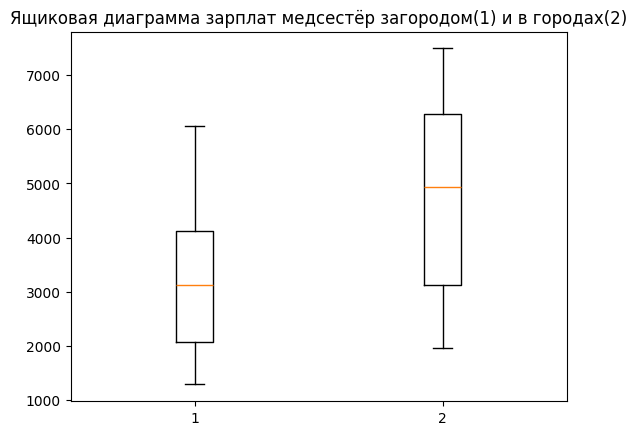

In [30]:
data_box = [rural.NSAL.tolist(), city.NSAL.tolist()]

plt.boxplot(data_box)
plt.title("Ящиковая диаграмма зарплат медсестёр загородом(1) и в городах(2)")

----

## Задача 2 

Unions and State Labor Law

In [ ]:
unions = pd.read_csv('/Users/d.kapanadze/Downloads/Учеба/ИТМО/2 семестр/Анализ данных на python/лаба1/Unions and State Labor Law/Unions and State Labor Law_data', sep='\s+')
unions.drop(['RTW', 'PVT'], axis=1, inplace=True)

In [56]:
unions.head()

,STATE,DENS,COMP
0,NY,56.9,1
1,MI,49.6,1
2,WA,32.4,1
3,HI,54.6,1
4,AK,30.7,1


In [62]:
law_pas = unions.query("COMP == 1")
law_rej = unions.query("COMP == 0")

print(law_pas.shape)
print(law_rej.shape)

(27, 3)
(23, 3)


<Axes: >

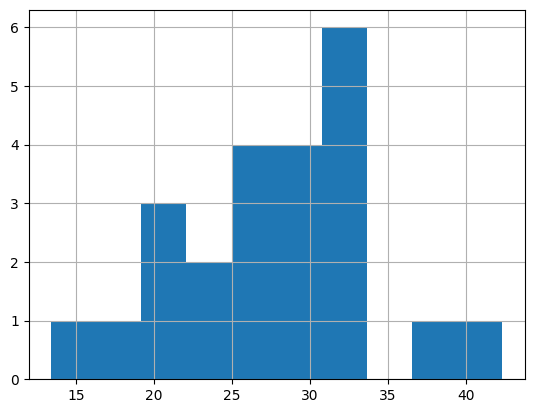

In [66]:
law_rej['DENS'].hist()

<Axes: >

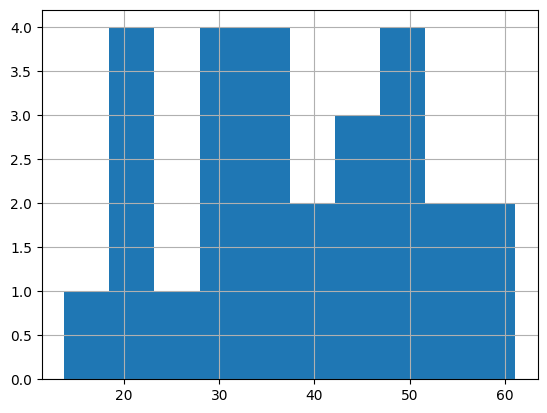

In [67]:
law_pas['DENS'].hist()

In [63]:
px.histogram(law_pas, x='DENS')

In [64]:
px.histogram(law_rej, x='DENS')

### Сложно понять нормально ли распределены данные, проведём тест Колмогорова-Смирнова

In [68]:
law_pas_list = law_pas.DENS.tolist()
law_pas_norm = law_pas_list - np.mean(law_pas_list) / np.std(law_pas_list, ddof=1)
ks_results = stats.kstest(law_pas_norm, 'norm')
print(ks_results.pvalue)

0.0


In [69]:
law_rej_list = law_rej.DENS.tolist()
law_rej_norm = law_rej_list - np.mean(law_rej_list) / np.std(law_rej_list, ddof=1)
ks_results = stats.kstest(law_rej_norm, 'norm')
print(ks_results.pvalue)

0.0


Поскольку распределения не нормальные, опять же воспользуемся тестом Манна-Уитни

In [70]:
mw_result = stats.mannwhitneyu(law_pas_list, law_rej_list)
print(mw_result.pvalue)

0.0019653510337949457


### P-value < 0.05 => Отвергаем гипотезу о равенстве медиан

Text(0.5, 1.0, 'Ящиковая диаграмма процента муниципальных служащих, состоящих в профсоюзах, в штатах где принят закон(1) и где он не принят(2)')

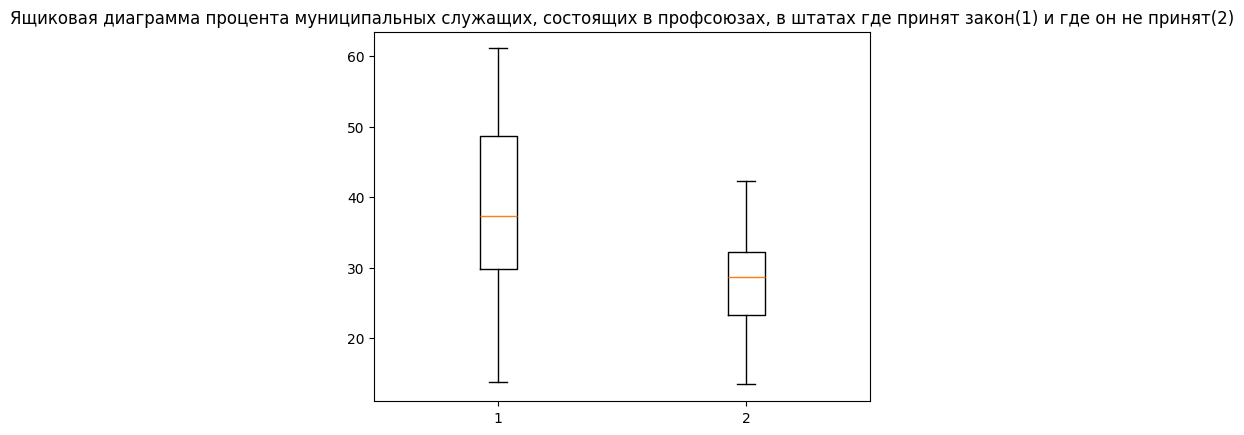

In [76]:
data_box = [law_pas.DENS.tolist(), law_rej_list]

plt.boxplot(data_box)
plt.title("Ящиковая диаграмма процента муниципальных служащих, состоящих в профсоюзах, в штатах где принят закон(1) и где он не принят(2)")